# 2. Data Understanding

Segunda fase do CRISP-DM. Aqui o objetivo é olhar para os dados pela primeira vez e responder a três perguntas práticas antes de pensar em qualquer modelo:

1. O dataset tem qualidade técnica suficiente para o trabalho? (tipos, missing, duplicatas)
2. As variáveis se comportam como o dicionário do PDF promete?
3. As 7 hipóteses formuladas no notebook 01 continuam viáveis com o que os dados realmente oferecem?

A ideia é separar o que precisa de tratamento (que vai para o notebook 03) do que está pronto para ser analisado direto. Vamos manter o tom narrativo: cada bloco de código vem acompanhado do raciocínio que motivou ele e da leitura do que ele produziu.

## 2.1 Carregamento e inspeção inicial

Antes de qualquer análise, três passos: carregar o CSV, conferir o formato e comparar o que veio com o que o dicionário do enunciado prometia. Se algo não bater (coluna a mais ou a menos, tipo errado, valor estranho), é melhor descobrir agora do que mais adiante.

Vou usar pandas como base, numpy para operações vetoriais, e configurar matplotlib e seaborn já no início do notebook para padronizar todas as figuras que aparecerem nas próximas seções.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reprodutibilidade — semente fixa para qualquer operação aleatória
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuração visual padrão (seaborn whitegrid + tamanho de figura legível)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Caminhos do projeto (relativos ao notebook em repo/notebooks/)
RAIZ_PROJETO = Path.cwd().parent
DADOS_BRUTOS = RAIZ_PROJETO / "data" / "raw" / "desafio_nps_fase_1.csv"
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "02_data_understanding"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carregamento da base
dados = pd.read_csv(DADOS_BRUTOS)

print(f"Linhas: {dados.shape[0]:,} | Colunas: {dados.shape[1]}")
print(f"Memória: {dados.memory_usage(deep=True).sum() / 1024:.1f} KB")

Linhas: 2,500 | Colunas: 19
Memória: 488.1 KB


O dicionário do enunciado lista 19 colunas, e o arquivo tem 2.500 linhas (uma linha por pedido, com `customer_id` repetindo quando o mesmo cliente fez mais de um pedido). A próxima checagem é olhar tipo de cada coluna para garantir que pandas interpretou tudo da forma esperada: variáveis numéricas como int ou float, e a região como string.

In [2]:
# Tipos de cada coluna e amostra das primeiras linhas
print("Tipos de dado por coluna:")
print(dados.dtypes.to_string())
print("\nPrimeiras linhas:")
dados.head(3)

Tipos de dado por coluna:
customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64

Primeiras linhas:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5


Os tipos vieram coerentes com o dicionário do PDF:

- **Identificadores e contagens** (`customer_id`, `order_id`, `customer_age`, `customer_tenure_months`, `items_quantity`, `payment_installments`, `delivery_time_days`, `delivery_delay_days`, `delivery_attempts`, `customer_service_contacts`, `resolution_time_days`, `complaints_count`, `repeat_purchase_30d`) vieram como `int64`. Faz sentido: são contagens e quantidades inteiras.
- **Valores monetários e scores** (`order_value`, `discount_value`, `freight_value`, `nps_score`, `csat_internal_score`) vieram como `float64`. Também coerente.
- **Região** (`customer_region`) veio como string. Vamos converter para categoria (`pd.Categorical`) lá no notebook 03, porque categoria ocupa menos memória e é mais rápida em comparações. Não é necessário fazer isso agora.

Um detalhe que vale comentar: o `nps_score` veio como `float`, com valores como 6.9, 2.4, 4.8 etc. O NPS canônico, definido por Reichheld em 2003, usa nota inteira de 0 a 10. Esse formato com decimais é incomum e merece investigação na seção 2.3, onde vamos olhar a distribuição da target em detalhe.

Antes de seguir, vale uma visão de alto nível das 19 variáveis: como elas se distribuem entre as áreas funcionais da operação. Isso ajuda a fixar mentalmente "onde mora cada coisa" antes de mergulhar nos detalhes.

Total de variáveis somadas: 19 (esperado: 19)


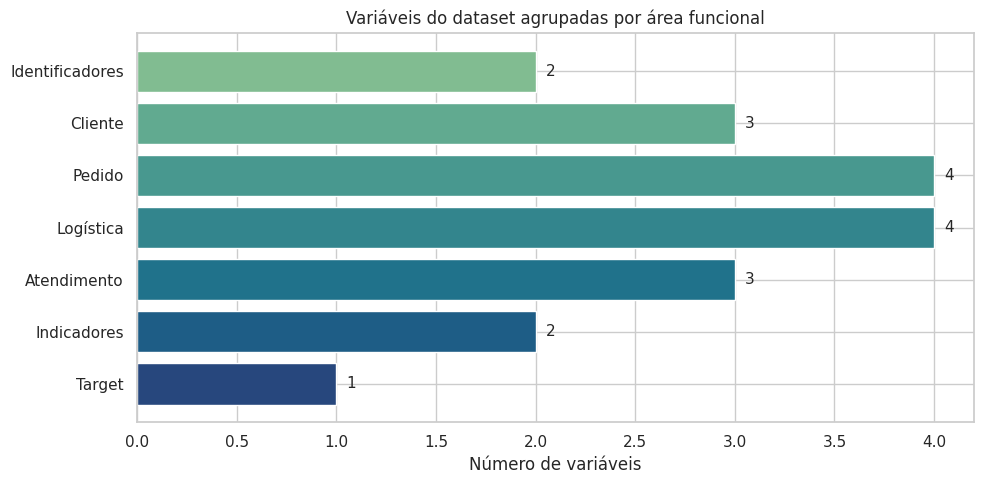

In [3]:
# Agrupamento das colunas por área funcional
grupos_colunas = {
    "Identificadores": ["customer_id", "order_id"],
    "Cliente":         ["customer_age", "customer_region", "customer_tenure_months"],
    "Pedido":          ["order_value", "items_quantity", "discount_value", "payment_installments"],
    "Logística":       ["delivery_time_days", "delivery_delay_days", "freight_value", "delivery_attempts"],
    "Atendimento":     ["customer_service_contacts", "resolution_time_days", "complaints_count"],
    "Indicadores":     ["repeat_purchase_30d", "csat_internal_score"],
    "Target":          ["nps_score"],
}

contagem_grupos = {nome: len(cols) for nome, cols in grupos_colunas.items()}

# Soma de checagem (deve dar 19)
total = sum(contagem_grupos.values())
print(f"Total de variáveis somadas: {total} (esperado: {dados.shape[1]})")

# Bar chart horizontal das categorias
fig, eixo = plt.subplots(figsize=(10, 5))
nomes = list(contagem_grupos.keys())
valores = list(contagem_grupos.values())

cores_grupos = sns.color_palette("crest", n_colors=len(nomes))
barras = eixo.barh(nomes, valores, color=cores_grupos)
for i, v in enumerate(valores):
    eixo.text(v + 0.05, i, str(v), va="center", fontsize=11)

eixo.set_xlabel("Número de variáveis")
eixo.set_title("Variáveis do dataset agrupadas por área funcional")
eixo.invert_yaxis()
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_1_perfil_variaveis_por_area.png", dpi=120, bbox_inches="tight")
plt.show()

![Variáveis do dataset agrupadas por área funcional](../reports/figures/02_data_understanding/2_1_perfil_variaveis_por_area.png)

## 2.2 Qualidade técnica

Antes de qualquer análise mais profunda, vale checar três coisas básicas: se há valores faltantes, se há linhas duplicadas, e qual é a granularidade real do dataset (uma linha equivale a um pedido, a um cliente, ou a algo intermediário?). Essas três checagens definem o que precisa de tratamento no notebook 03 e o que já está pronto para usar.

In [4]:
# Quantos valores faltantes em cada coluna
print("Valores faltantes por coluna:")
print(dados.isna().sum().to_string())
print(f"\nTotal de missing no dataset: {dados.isna().sum().sum()}")

Valores faltantes por coluna:
customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0

Total de missing no dataset: 0


Zero valores faltantes em qualquer coluna. Isso é incomum em datasets reais de e-commerce: normalmente alguma coluna sofre com falha de coleta, integração entre sistemas ou cliente que não preencheu campo. Aqui não tem nada disso.

A leitura mais provável é que o dataset foi pré-tratado para o exercício, ou foi gerado de forma sintética. Para o trabalho, isso simplifica bastante: não vamos gastar tempo com imputação ou estratégia de tratamento de missing no notebook 03. Mas é importante registrar que essa "limpeza perfeita" é uma característica do dataset acadêmico, e na prática a empresa real precisaria lidar com missing.

In [5]:
# Linhas inteiramente duplicadas
linhas_duplicadas = dados.duplicated().sum()
print(f"Linhas duplicadas (todas as colunas iguais): {linhas_duplicadas}")

# Unicidade dos identificadores
print(f"\norder_id únicos:    {dados['order_id'].nunique():,} de {len(dados):,} linhas")
print(f"customer_id únicos: {dados['customer_id'].nunique():,} de {len(dados):,} linhas")

# Distribuição de pedidos por cliente
pedidos_por_cliente = dados['customer_id'].value_counts()
print(f"\nDistribuição de pedidos por cliente:")
print(pedidos_por_cliente.value_counts().sort_index().to_string())

Linhas duplicadas (todas as colunas iguais): 0

order_id únicos:    2,500 de 2,500 linhas
customer_id únicos: 2,500 de 2,500 linhas

Distribuição de pedidos por cliente:
count
1    2500


Três achados importantes nessa célula:

1. **Nenhuma linha duplicada.** Cada registro é único, sem repetição idêntica.
2. **Cada `order_id` aparece uma vez.** Os 2.500 pedidos são todos distintos.
3. **Cada `customer_id` aparece uma vez.** São 2.500 clientes diferentes, cada um com exatamente um pedido.

O terceiro ponto é o mais relevante para a análise. O dataset não é um histórico longitudinal (cliente comprando várias vezes ao longo do tempo): é um snapshot de pedidos, onde cada cliente entra com uma única observação. Isso tem três implicações práticas:

- **Granularidade da análise:** linha = pedido = cliente. Não precisamos de agregação por cliente; cada estatística que calcularmos no nível do pedido é também a estatística no nível do cliente.
- **Variável `customer_tenure_months`:** descreve o tempo de relacionamento do cliente com a empresa, mas só temos uma foto desse cliente. Não dá para analisar como a satisfação dele variou conforme o tenure cresceu. Tenure é uma característica fixa do cliente nesta base, não uma trajetória.
- **Hipótese H5 (NPS prediz recompra):** o `repeat_purchase_30d` é uma variável binária que indica se o cliente comprou de novo em até 30 dias depois deste pedido. A próxima compra existe no mundo real, mas não está no dataset; só temos o flag de que ela ocorreu (1) ou não (0). Para a hipótese H5 isso é suficiente, basta cruzar `nps_score` com `repeat_purchase_30d`.

Como a checagem de missing deu zero em todas as colunas, vale também uma confirmação visual. Em datasets reais, esse gráfico costuma mostrar faixas de "buracos" claros indicando onde a coleta falhou. Aqui o mapa vai aparecer todo preenchido.

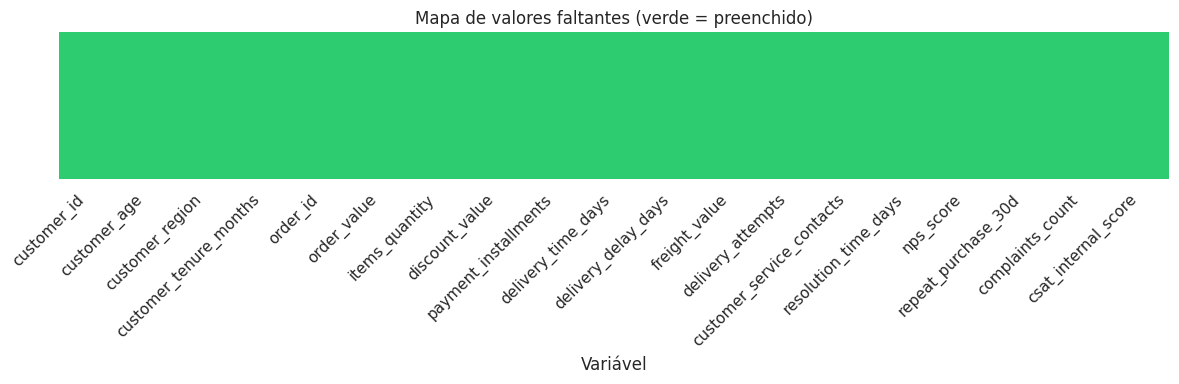

In [6]:
# Mapa visual de valores faltantes
fig, eixo = plt.subplots(figsize=(12, 4))
mascara_missing = dados.isna()
sns.heatmap(
    mascara_missing,
    cbar=False,
    cmap=["#2ecc71"],
    yticklabels=False,
    ax=eixo,
)
eixo.set_title("Mapa de valores faltantes (verde = preenchido)")
eixo.set_xlabel("Variável")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_2_mapa_missing.png", dpi=120, bbox_inches="tight")
plt.show()

![Mapa de valores faltantes — todas as células preenchidas](../reports/figures/02_data_understanding/2_2_mapa_missing.png)